In [255]:
import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(".."))
from src.data_cleaning import load_path
from src.segementFunc import segement_customer

In [256]:
df=load_path("../data/processed/data_clean.csv")

In [257]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [258]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [259]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [260]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [261]:
df.shape

(406829, 8)

In [262]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,406829.000000,406829,406829.000000,406829.000000
mean,12.061303,2011-07-10 16:30:57.879207424,3.460471,15287.690570
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13953.000000
50%,5.000000,2011-07-31 11:48:00,1.950000,15152.000000
75%,12.000000,2011-10-20 13:06:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,248.693370,NaN,69.315162,1713.600303


In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406829 entries, 0 to 406828
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 24.8+ MB


In [264]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [265]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [266]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [267]:
df['InvoiceNo'].dtypes


dtype('O')

In [268]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [269]:
cancelProductData=df[df['InvoiceNo'].astype(str).str.startswith("C")]

cancelProductData.count()

InvoiceNo      8905
StockCode      8905
Description    8905
Quantity       8905
InvoiceDate    8905
UnitPrice      8905
CustomerID     8905
Country        8905
TotalPrice     8905
dtype: int64

### Cancelled / Returned Transactions
- Out of approximately **400,000 total transactions**, around **8,905** correspond to returns or cancellations.
- The remaining transactions represent **successful purchase activity** and were used for revenue and RFM analysis.
- Returns account for a **small but non-negligible portion** of overall activity and reflect an important customer behavior dimension.

In [270]:
returns = df[df["Quantity"] < 0].groupby("CustomerID").agg({
    "InvoiceNo": "nunique",#count unique values
    "Quantity": "sum",
    "TotalPrice": "sum"
})

returns.columns = ["Return_Count", "Total_Items_Returned", "Return_Value"]
returns.head()

,Return_Count,Total_Items_Returned,Return_Value
CustomerID,,,
12346.0,1,-74215,-77183.60
12352.0,3,-66,-960.63
12359.0,2,-10,-127.05
12362.0,3,-17,-71.65
12365.0,1,-1,-320.69


In [271]:
df[df['CustomerID']==12346.0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
38120,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6
38125,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,-77183.6


### Returns Behavior Consideration
- Returns and cancellations were excluded from RFM analysis to ensure accurate customer value segmentation.
- Return behavior represents a different dimension of customer interaction and will be analyzed separately.
- This separation allows clearer identification of high-value customers versus high-return-risk customers.

In [272]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,406829.000000,406829,406829.000000,406829.000000,406829.000000
mean,12.061303,2011-07-10 16:30:57.879207424,3.460471,15287.690570,20.401854
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,-168469.600000
25%,2.000000,2011-04-06 15:02:00,1.250000,13953.000000,4.200000
50%,5.000000,2011-07-31 11:48:00,1.950000,15152.000000,11.100000
75%,12.000000,2011-10-20 13:06:00,3.750000,16791.000000,19.500000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,248.693370,NaN,69.315162,1713.600303,427.591718


**compute RFM metrics:Recency(How recently a customer made a purchase),Freqeuncy(how often a customer purchases),Monetary(How much money customer spent)**

In [273]:
df=df[
    (df['Quantity']>0)&
    (df['UnitPrice']>0)&
      (~df['InvoiceNo'].astype(str).str.startswith("C"))
        ]
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


In [274]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']

In [275]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [276]:
refernce_date=df['InvoiceDate'].max()+pd.Timedelta(days=1)
refernce_date

Timestamp('2011-12-10 12:50:00')

In [277]:
df.shape

(397884, 9)

In [278]:
rfm=df.groupby('CustomerID').agg({
    'InvoiceDate':lambda x:(refernce_date-x.max()).days,#recency
    'InvoiceNo':'nunique',#frequency
    'TotalPrice':'sum'#Monetory
})
rfm.columns=['Recency','Frequency','Monetory']
rfm.head(10)

,Recency,Frequency,Monetory
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
12353.0,204,1,89.00
12354.0,232,1,1079.40
12355.0,214,1,459.40


In [279]:
rfm.describe()

,Recency,Frequency,Monetory
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


### RFM Base Table Creation
- Converted transaction-level data into customer-level aggregates.
- Removed cancellations and negative values to reflect true purchasing behavior.
- Created Recency, Frequency, and Monetary metrics for each customer.

In [280]:
customer_profile = rfm.merge(
    returns,
    how="left",
    left_index=True,
    right_index=True
)

In [281]:
customer_profile.head()

,Recency,Frequency,Monetory,Return_Count,Total_Items_Returned,Return_Value
CustomerID,,,,,,
12346.0,326,1,77183.60,1.0,-74215.0,-77183.6
12347.0,2,7,4310.00,NaN,NaN,NaN
12348.0,75,4,1797.24,NaN,NaN,NaN
12349.0,19,1,1757.55,NaN,NaN,NaN
12350.0,310,1,334.40,NaN,NaN,NaN


In [282]:
customer_profile=customer_profile.fillna(0)

In [283]:
customer_profile.head()

,Recency,Frequency,Monetory,Return_Count,Total_Items_Returned,Return_Value
CustomerID,,,,,,
12346.0,326,1,77183.60,1.0,-74215.0,-77183.6
12347.0,2,7,4310.00,0.0,0.0,0.0
12348.0,75,4,1797.24,0.0,0.0,0.0
12349.0,19,1,1757.55,0.0,0.0,0.0
12350.0,310,1,334.40,0.0,0.0,0.0


### Customer Purchase and Return Profile
- Combined RFM purchase metrics with return behavior at the customer level.
- Purchase and return data were merged to avoid mixing different behavioral signals.
- This enables identification of high-value customers with unusual return patterns.
- Some customers place large orders and subsequently return the entire purchase.
- Such transactions were excluded from RFM calculations to preserve accurate customer value measurement.
- Return behavior was captured separately to identify high-risk or dissatisfied customers.
> RFM metrics were calculated using successful purchase transactions only. Return and cancellation behavior was analyzed separately to avoid distortion of customer value signals.

In [284]:
rfm.describe()

,Recency,Frequency,Monetory
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


### RFM Distribution Insights
- Customer behavior is highly skewed, with most customers purchasing infrequently and spending modest amounts.
- A small group of customers shows very high frequency and monetary value, contributing disproportionately to total revenue.
- While many customers have not purchased recently, some infrequent visitors still generate high total spending, indicating diverse purchasing patterns.
- The positive skew in monetary value suggests that revenue is concentrated among a limited number of high-value customers.
### Correct Interpretation of RFM Distributions
- 25% of customers made their most recent purchase within the last 18 days.
- 25% of customers purchased only once.
- 25% of customers spent less than $307 in total.
- These metrics describe independent distributions and do not imply that the same customers fall into all three categories simultaneously.

In [285]:
rfm['R_score']=pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]#lower recency means customer visit oftenly so i label them as 4 (high score)
).astype(int)# Divide data into bins with (approximately) equal number of observations.
#mport pandas as pd data = [10, 20, 30, 40, 50, 60, 70, 80]pd.qcut(data, 4, labels=False)
#[0, 0, 1, 1, 2, 2, 3, 3] gives index to each item and divide data into 4 group using quartile
#So yes, it’s like breaking a stick into 4 equal parts by cutting it 3 times(25%,50%,75%) — 
# but instead of physical length, the cuts are based on data distribution (quantiles).



In [286]:
rfm['F_score']=pd.qcut(
    rfm['Frequency'].rank(method="first"),
    4,
    labels=[1,2,3,4]#since here high frequency of customer is defined good so high score for high frequency is 4 unlike recency,
    #since this divide the groups in 4 part like (lowest->lower->higher->highest) just raw value,so we rank them in renency term
    #we label lower as high score since customer is visiting often
).astype(int)

In [287]:
rfm['M_score']=pd.qcut(
    rfm['Monetory'],
    4,
    labels=[1,2,3,4]
).astype(int)

In [288]:
rfm["RFM_score"]=(
    rfm["R_score"].astype(str)+
    rfm["F_score"].astype(str)+
    rfm["M_score"].astype(str)
)#444 best customer

In [289]:
rfm.head()

,Recency,Frequency,Monetory,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [290]:
best_customer=rfm[rfm["RFM_score"]=="444"]

In [291]:
best_customer.head()

,Recency,Frequency,Monetory,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12347.0,2,7,4310.00,4,4,4,444
12362.0,3,10,5226.23,4,4,4,444
12388.0,16,6,2780.66,4,4,4,444
12417.0,3,9,3649.10,4,4,4,444
12423.0,1,8,1859.31,4,4,4,444


In [292]:
best_customer.count()

Recency      490
Frequency    490
Monetory     490
R_score      490
F_score      490
M_score      490
RFM_score    490
dtype: int64

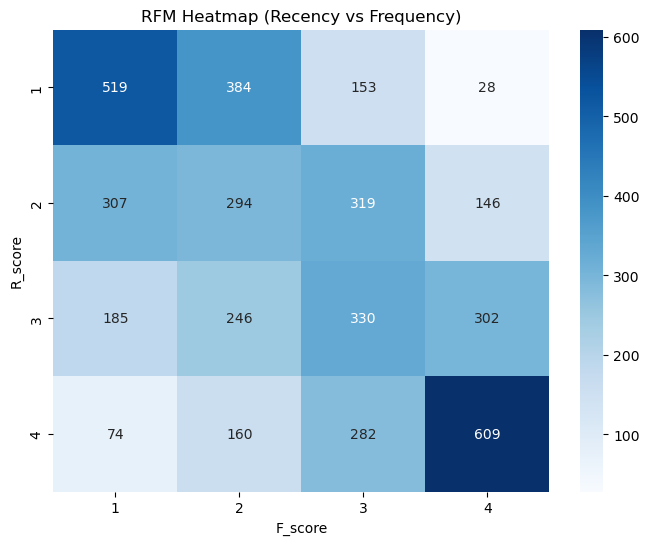

In [293]:
# Count customers by RFM score
rfm_counts = rfm.groupby(["R_score","F_score"]).size().reset_index(name="count")

# Pivot for heatmap
rfm_matrix = rfm_counts.pivot(index="R_score", columns="F_score", values="count")

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(rfm_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("RFM Heatmap (Recency vs Frequency)")
plt.show()


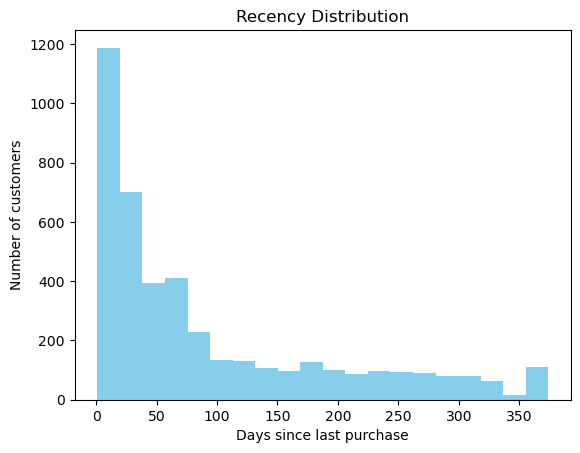

Recency = 1: 93
Recency <= 18: 1125
Recency <= 51: 2188


In [294]:

plt.hist(rfm['Recency'], bins=20, color='skyblue')
plt.title("Recency Distribution")
plt.xlabel("Days since last purchase")
plt.ylabel("Number of customers")
plt.show()

# Customers with Recency = 1
recent_one_day = rfm[rfm['Recency'] == 1].shape[0]

# Customers with Recency <= 18
recent_18_days = rfm[rfm['Recency'] <= 18].shape[0]

recent_51_days=rfm[rfm['Recency']<=51].shape[0]

print("Recency = 1:", recent_one_day)
print("Recency <= 18:", recent_18_days)
print("Recency <= 51:", recent_51_days)

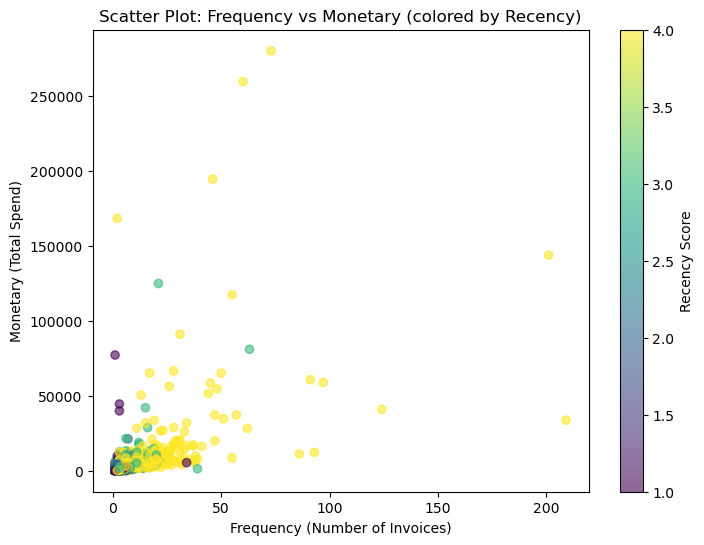

In [295]:
plt.figure(figsize=(8,6))
plt.scatter(rfm['Frequency'], rfm['Monetory'], alpha=0.6, c=rfm['R_score'], cmap='viridis')
plt.title("Scatter Plot: Frequency vs Monetary (colored by Recency)")
plt.xlabel("Frequency (Number of Invoices)")
plt.ylabel("Monetary (Total Spend)")
plt.colorbar(label="Recency Score")
plt.show()

In [296]:
rfm["RFM_score"].value_counts().head(10)

RFM_score
444    490
111    303
344    213
121    187
112    170
333    158
233    157
211    147
433    135
122    129
Name: count, dtype: int64

### RFM Scoring
- Customers were scored into quartiles for Recency, Frequency, and Monetary value.
- Lower recency and higher frequency/monetary values indicate stronger customer engagement.
- Combined RFM scores enable comparison and segmentation of customer value.

In [297]:
rfm[rfm['Recency'] <=18].shape[0]

1125

In [298]:
rfm=rfm.reset_index()

In [299]:
rfm['segment']=rfm.apply(segement_customer,axis=1)


In [300]:
rfm['segment'].value_counts()

segment
Champions             1319
Lost customers        1153
Loyal_cusomter         764
Potenial Loyalists     699
At risk                403
Name: count, dtype: int64

In [301]:
rfm.head()

,CustomerID,Recency,Frequency,Monetory,R_score,F_score,M_score,RFM_score,segment
0,12346.0,326,1,77183.60,1,1,4,114,Lost customers
1,12347.0,2,7,4310.00,4,4,4,444,Champions
2,12348.0,75,4,1797.24,2,3,4,234,Loyal_cusomter
3,12349.0,19,1,1757.55,3,1,4,314,Potenial Loyalists
4,12350.0,310,1,334.40,1,1,2,112,Lost customers


In [302]:
rfm.groupby("segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetory":'mean',
    "CustomerID": "count"
}).rename(columns={"CustomerID": "Customer_Count"})

,Recency,Frequency,Monetory,Customer_Count
segment,,,,
At risk,156.007444,1.751861,795.185635,403
Champions,17.094769,9.376801,4932.935550,1319
Lost customers,195.519514,1.147441,396.882325,1153
Loyal_cusomter,95.632199,4.036649,1462.905014,764
Potenial Loyalists,25.045780,1.503577,728.385336,699


In [303]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 406828
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [304]:
print(rfm.columns)

Index(['CustomerID', 'Recency', 'Frequency', 'Monetory', 'R_score', 'F_score',
       'M_score', 'RFM_score', 'segment'],
      dtype='object')


### Customer Segmentation Using RFM
- Customers were grouped into meaningful segments based on RFM score combinations.
- A small group of Champions and Loyal Customers contributes disproportionately to revenue.
- Several customers fall into At-Risk and Lost segments, highlighting retention and reactivation opportunities.
- Return behavior provides additional context for identifying high-value but high-risk customers.